##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [54]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Pose Landmarks Detection with MediaPipe Tasks

This notebook shows you how to use MediaPipe Tasks Python API to detect pose landmarks from images.

## Preparation

Let's start with installing MediaPipe.


In [55]:
!pip3 install -q mediapipe

Then download an off-the-shelf model bundle. Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker#models) for more information about this model bundle.

In [56]:
import urllib.request
import os

model_url = 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task'
model_path = 'pose_landmarker.task'

if not os.path.exists(model_path):
    print("Downloading pose_landmarker model...")
    urllib.request.urlretrieve(model_url, model_path)
    print(f"Model downloaded successfully to {model_path}")
else:
    print(f"Model file already exists at {model_path}")


Model file already exists at pose_landmarker.task


## Visualization utilities

In [57]:
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

## Download test image

To demonstrate the Pose Landmarker API, you can download a sample image using the follow code. The image is from [Pixabay](https://pixabay.com/photos/girl-woman-fitness-beautiful-smile-4051811/).

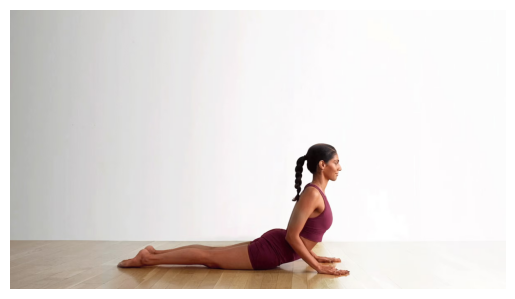

In [3]:
import cv2
import matplotlib.pyplot as plt

def cv2_imshow(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

IMAGE_FILE = "images/cobra1.jpg"
img = cv2.imread(IMAGE_FILE)
if img is not None:
    cv2_imshow(img)
else:
    print(f"Could not read {IMAGE_FILE}. Please make sure it's downloaded correctly.")


## Running inference and visualizing the results

The final step is to run pose landmark detection on your selected image. This involves creating your PoseLandmarker object, loading your image, running detection, and finally, the optional step of displaying the image with visualizations.

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker/python) to learn more about configuration options that this solution supports.


In [3]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2 # Ensure cv2 is imported here too
import numpy as np

# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

print("completed creating PoseLandmarker object")

I0000 00:00:1775340436.309456 3080231 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M2
W0000 00:00:1775340436.393562 3080235 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775340436.500314 3080235 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:

def output_joints_image(IMAGE_FILE, detector):
    # Read image with OpenCV (converts BGR to RGB)
    cv_image = cv2.imread(IMAGE_FILE)
    if cv_image is None:
        print(f"Error: Could not load image from {IMAGE_FILE}")
    else:
        # Convert BGR to RGB for MediaPipe
        rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
        # Create MediaPipe Image from numpy array
        image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
        
        # STEP 4: Detect pose landmarks from the input image.
        detection_result = detector.detect(image)
        
        # STEP 5: Process the detection result. In this case, visualize it.
        annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
        cv2_imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

# STEP 3: Load the input image using OpenCV
IMAGE_FILE_1 = "images/balancing_table/balancing_table1.jpg"
IMAGE_FILE_2 = "images/balancing_table/balancing_table2.jpg"
output_joints_image(IMAGE_FILE_1, detector)
output_joints_image(IMAGE_FILE_2, detector)


Visualize the pose segmentation mask.

In [5]:
segmentation_mask = detection_result.segmentation_masks[0].numpy_view()
segmentation_mask = np.squeeze(segmentation_mask)

# Convert to 3‑channel uint8 image for visualization.
visualized_mask = (segmentation_mask * 255).astype(np.uint8)
visualized_mask = np.stack([visualized_mask]*3, axis=-1)

# Display the segmentation mask as an image
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Segmentation Mask (grayscale)')
plt.imshow(segmentation_mask, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Visualized Mask (RGB)')
plt.imshow(visualized_mask)
plt.axis('off')
plt.show()

# Print a small part of the mask array
print('Segmentation mask sample:', segmentation_mask[:5,:5])
print('Visualized mask sample:', visualized_mask[:2,:2,:])

KeyboardInterrupt: 

In [9]:
# --- Joint Angle Extraction and Comparison Utilities ---
import math

# MediaPipe pose landmark indices for major joints
JOINTS = {
    'left_shoulder': 11,
    'right_shoulder': 12,
    'left_elbow': 13,
    'right_elbow': 14,
    'left_wrist': 15,
    'right_wrist': 16,
    'left_hip': 23,
    'right_hip': 24,
    'left_knee': 25,
    'right_knee': 26,
    'left_ankle': 27,
    'right_ankle': 28
}

# Helper: angle between three points (in degrees)
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

# Extract joint coordinates from detection result
def get_landmark_coords(landmarks, image_shape):
    h, w = image_shape[:2]
    coords = {}
    for name, idx in JOINTS.items():
        lm = landmarks[idx]
        coords[name] = (lm.x * w, lm.y * h)
    return coords

# Calculate all major joint angles
def get_joint_angles(landmarks, image_shape):
    coords = get_landmark_coords(landmarks, image_shape)
    angles = {}
    # Shoulders (angle at shoulder: hip-shoulder-elbow)
    angles['left_shoulder'] = calculate_angle(coords['left_hip'], coords['left_shoulder'], coords['left_elbow'])
    angles['right_shoulder'] = calculate_angle(coords['right_hip'], coords['right_shoulder'], coords['right_elbow'])
    # Elbows (angle at elbow: shoulder-elbow-wrist)
    angles['left_elbow'] = calculate_angle(coords['left_shoulder'], coords['left_elbow'], coords['left_wrist'])
    angles['right_elbow'] = calculate_angle(coords['right_shoulder'], coords['right_elbow'], coords['right_wrist'])
    # Hips (angle at hip: shoulder-hip-knee)
    angles['left_hip'] = calculate_angle(coords['left_shoulder'], coords['left_hip'], coords['left_knee'])
    angles['right_hip'] = calculate_angle(coords['right_shoulder'], coords['right_hip'], coords['right_knee'])
    # Knees (angle at knee: hip-knee-ankle)
    angles['left_knee'] = calculate_angle(coords['left_hip'], coords['left_knee'], coords['left_ankle'])
    angles['right_knee'] = calculate_angle(coords['right_hip'], coords['right_knee'], coords['right_ankle'])
    return angles

# Compare two sets of joint angles and print corrections
def compare_joint_angles(ref_angles, test_angles, threshold=10):
    print("Joint angle comparison (degrees):")
    for joint in ref_angles:
        ref = ref_angles[joint]
        test = test_angles[joint]
        diff = test - ref
        if abs(diff) > threshold:
            print(f"{joint}: {test:.1f}° (should be {ref:.1f}°) -> Correction: {(-diff):+.1f}°")
        else:
            print(f"{joint}: {test:.1f}° (OK)")

# --- Example usage ---
# 1. Run pose detection on two images to get detection_result1 and detection_result2
# 2. For each, extract the first pose landmarks:
#    landmarks1 = detection_result1.pose_landmarks[0]
#    landmarks2 = detection_result2.pose_landmarks[0]
# 3. Get joint angles:
#    angles1 = get_joint_angles(landmarks1, rgb_image.shape)
#    angles2 = get_joint_angles(landmarks2, rgb_image.shape)
# 4. Compare:
#    compare_joint_angles(angles1, angles2)

# To use: Replace detection_result1 and detection_result2 with your results for two images.

In [6]:
# --- Joint Angle Extraction and Comparison for two different images of the same pose---
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Helper to run pose detection and get angles
def get_angles_for_image(image_path, detector):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_img)
    result = detector.detect(mp_image)
    if not result.pose_landmarks:
        print(f"No pose detected in {image_path}")
        return None, None
    angles = get_joint_angles(result.pose_landmarks[0], rgb_img.shape)
    return angles, img

# Ensure detector is created (reuse from previous cell if possible)
try:
    detector
except NameError:
    base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True)
    detector = vision.PoseLandmarker.create_from_options(options)


In [ ]:

# Get joint angles for both images
angles1, img1 = get_angles_for_image('balancing_table1.jpg', detector)
angles2, img2 = get_angles_for_image('balancing_table2.jpg', detector)

if angles1 and angles2:
    print('Joint angles for balancing_table1.jpg:')
    for joint, angle in angles1.items():
        print(f'{joint}: {angle:.1f}°')
    print('\nJoint angles for balancing_table2.jpg:')
    for joint, angle in angles2.items():
        print(f'{joint}: {angle:.1f}°')
    print('\nJoint angle differences (balancing_table2 - balancing_table1):')
    for joint in angles1:
        diff = angles2[joint] - angles1[joint]
        print(f'{joint}: {diff:+.1f}°')
else:
    print('Could not compute joint angles for both images.')

In [10]:
# --- Ground Truth Calculation ---
# Calculate the average joint angles from image 1, 2, and 3 for a given pose
def calculate_ground_truth(pose_name, detector):
    image_paths = [
        f"images/{pose_name}/{pose_name}1.jpg",
        f"images/{pose_name}/{pose_name}2.jpg",
        f"images/{pose_name}/{pose_name}3.jpg"
    ]
    
    all_angles = []
    for path in image_paths:
        angles, _ = get_angles_for_image(path, detector)
        if angles:
            all_angles.append(angles)
            
    if not all_angles:
        print(f"Could not calculate ground truth for {pose_name}")
        return None
        
    # Calculate average for each joint
    ground_truth = {}
    for joint in all_angles[0].keys():
        joint_angles = [angles[joint] for angles in all_angles if joint in angles]
        ground_truth[joint] = sum(joint_angles) / len(joint_angles)
        
    return ground_truth

# Example for balancing_table
pose_name = 'balancing_table'
ground_truth_angles = calculate_ground_truth(pose_name, detector)

if ground_truth_angles:
    print(f"Ground Truth Angles for {pose_name}:")
    for joint, angle in ground_truth_angles.items():
        print(f"{joint}: {angle:.1f}°")


Ground Truth Angles for balancing_table:
left_shoulder: 114.0°
right_shoulder: 131.5°
left_elbow: 172.6°
right_elbow: 168.3°
left_hip: 149.1°
right_hip: 116.6°
left_knee: 147.2°
right_knee: 111.6°


In [11]:
# --- Compare User Input (Images 4 and 5) with Ground Truth ---
def compare_with_user_input(pose_name, user_image_paths, ground_truth, detector, threshold=10):
    for path in user_image_paths:
        print(f"\n--- Comparing User Input: {path} ---")
        user_angles, _ = get_angles_for_image(path, detector)
        
        if not user_angles:
            print(f"Could not get angles for {path}")
            continue
            
        print("Comparison with Ground Truth:")
        for joint in ground_truth:
            ref = ground_truth[joint]
            test = user_angles.get(joint)
            if test is None:
                continue
            
            diff = test - ref
            if abs(diff) > threshold:
                print(f"{joint}: {test:.1f}° (Target: {ref:.1f}°) -> Correction: {(-diff):+.1f}°")
            else:
                print(f"{joint}: {test:.1f}° (OK)")

# Example comparing with user input files 4 and 5
user_inputs = [
    f"images/{pose_name}/{pose_name}4.jpg",
    f"images/{pose_name}/{pose_name}5.jpg"
]

if ground_truth_angles:
    compare_with_user_input(pose_name, user_inputs, ground_truth_angles, detector)



--- Comparing User Input: images/balancing_table/balancing_table4.jpg ---
Comparison with Ground Truth:
left_shoulder: 77.9° (Target: 114.0°) -> Correction: +36.1°
right_shoulder: 163.4° (Target: 131.5°) -> Correction: -31.9°
left_elbow: 179.9° (OK)
right_elbow: 173.8° (OK)
left_hip: 173.3° (Target: 149.1°) -> Correction: -24.2°
right_hip: 98.1° (Target: 116.6°) -> Correction: +18.5°
left_knee: 175.2° (Target: 147.2°) -> Correction: -27.9°
right_knee: 83.4° (Target: 111.6°) -> Correction: +28.2°

--- Comparing User Input: images/balancing_table/balancing_table5.jpg ---
Comparison with Ground Truth:
left_shoulder: 80.4° (Target: 114.0°) -> Correction: +33.6°
right_shoulder: 145.6° (Target: 131.5°) -> Correction: -14.1°
left_elbow: 173.7° (OK)
right_elbow: 158.8° (OK)
left_hip: 170.0° (Target: 149.1°) -> Correction: -20.9°
right_hip: 105.6° (Target: 116.6°) -> Correction: +11.0°
left_knee: 165.3° (Target: 147.2°) -> Correction: -18.1°
right_knee: 81.2° (Target: 111.6°) -> Correction: +3